In [ ]:
# # 0. (optional but safer) start clean
# !pip uninstall -y torch torchvision torchaudio torch-geometric torch-scatter torch-sparse torch-cluster torch-spline-conv

# # 1. Install fairchem FIRST (this pins torch to 2.6.x)
# !pip install git+https://github.com/facebookresearch/fairchem.git@fairchem_core-2.0.0#subdirectory=packages/fairchem-core

# # 2. Now detect the actual torch version it installed
# import torch
# TORCH_VER = torch.__version__.split('+')[0]
# CUDA_VER = 'cu' + torch.version.cuda.replace('.', '')
# print(f"Detected: torch={TORCH_VER} {CUDA_VER}")

# # 3. Install matching PyG wheels (NOW correct)
# !pip install torch-scatter torch-sparse torch-cluster torch-spline-conv \
#   -f https://data.pyg.org/whl/torch-{TORCH_VER}+{CUDA_VER}.html

# # 4. Install torch_geometric
# !pip install torch_geometric

In [1]:
import torch, torch_geometric, fairchem.core
from torch_cluster import radius_graph
print("Torch:", torch.__version__)
print("PyG:", torch_geometric.__version__)
print("Fairchem:", fairchem.core.__version__)
print("radius_graph: OK")

Torch: 2.6.0+cu124
PyG: 2.7.0
Fairchem: 2.0.0
radius_graph: OK


In [ ]:
# !pip install git+https://github.com/facebookresearch/fairchem.git@fairchem_core-2.0.0#subdirectory=packages/fairchem-core

In [8]:
# colab
!git clone https://github.com/yasheshak/Chem-277B-Final-Project.git

Cloning into 'Chem-277B-Final-Project'...
remote: Enumerating objects: 179, done.
remote: Counting objects: 100% (179/179), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 179 (delta 88), reused 114 (delta 43), pack-reused 0 (from 0)
Receiving objects: 100% (179/179), 2.28 MiB | 21.66 MiB/s, done.
Resolving deltas: 100% (88/88), done.


In [9]:
%cd Chem-277B-Final-Project

/content/Chem-277B-Final-Project/Chem-277B-Final-Project


In [10]:
!git pull

Already up to date.


In [11]:
!ls -a

.			    extract.py		      read_multi_ase.py
..			    .git		      SchNet_for_import.py
db_explore.ipynb	    .gitignore		      SchNet_GNN_Baseline.ipynb
DimeNet_baseline_new.ipynb  hyperparam_test.ipynb     SchNet_GNN.ipynb
.DS_Store		    hyperparam_test_v2.ipynb  SchNet_Normalize.ipynb
EDA			    Makefile		      simpleGNN
EDA.ipynb		    __pycache__
environment.yml		    README.md


In [12]:
from google.colab import auth
auth.authenticate_user()

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Goal: Optimizer hyperparameters

Plan
1. Baseline sweep: identify how sensitive the model is when changing target parameter. A range of values for a single parameter is tested while keeping the other params at its default value.
    - Narrow down hyperparameter values
2. Grid search: explores interactions between hyperparameters by examining every possible combination.

Baseline sweep
1. create dict of start, stop, min (user defined)


In [13]:
# system imports
import os
import sys
import time
sys.path.append('/content/Chem-277B-Final-Project')

# local imports
from read_multi_ase import *
from extract import *
from SchNet_for_import import *

import glob
from typing import Union

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import random_split

# pytorch
from torch_geometric.data import Data
from torch_geometric.nn import SchNet
from torch_geometric.loader import DataLoader

# fairchem
from fairchem.core.datasets import AseDBDataset

In [31]:
# ---------------------------------- Initialize hyperparam range -------------------------------
# parameters to optimize
# num channels 64 - 256
hidden_channels = {
    'name': 'hidden_channels',
    'start': 1,
    'end': 2,
    'step': 1
}
# num_filters
num_filters = {
    'name': 'num_filters',
    'start': 1,
    'end': 2,
    'step': 1
}
# num_interactions
num_interactions = {
    'start': 1,
    'end': 1,
    'step': 1
}
# num_gaussians
num_gaussians = {
    'start': 1,
    'end': 1,
    'step': 1
}
# cutoff # 4 - 12
cutoff = {
    'start': 1,
    'end': 1,
    'step': 1
}
# max_num_neighbors
max_num_neighbors = {
    'start': 1,
    'end': 1,
    'step': 1
}

params_to_optimize = [hidden_channels, num_filters, num_interactions, num_gaussians, cutoff, max_num_neighbors]

#
param_mapping = {
    'hidden_channels': 128,
    'num_filters': 128,
    'num_interactions': 6,
    'num_gaussians': 50,
    'cutoff': 5,
    'max_num_neighbors': 32
}

# initialize default params
default_params = {
'hidden_channels': 128,
'num_filters': 128,
'num_interactions': 6,
'num_gaussians': 50,
'cutoff': 5,
'max_num_neighbors': 32
}

In [33]:
# ------------------------------- Final Function -------------------------------------------
def param_tuning(param: str,
                 param_start: int,
                 param_end: int,
                 param_step: int,
                 file_path_to_save: str,
                 train_data,
                 val_data,
                 test_data):

    # initialize numpy array for param vals
    param_vals = np.arange(start=param_start, stop=(param_end+1), step=param_step)

    # initialize params
    params = default_params.copy()

    rows = []
    for val in param_vals:
      # update param dict
      params[param] = val

      device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

      #Initialize model with desired parameters
      model = SchNetModel(
          params['hidden_channels'],
          params['num_filters'],
          params['num_interactions'],
          params['num_gaussians'],
          params['cutoff'],
          params['max_num_neighbors'],
          readout = "add",
          dipole = False,
          mean = None,
          std = None,
          atomref = None,
          train_mean = None,
          train_std = None
      ).to(device)

      optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
      loss_function = torch.nn.SmoothL1Loss()

      # run model
      epochs = 50
      train_losses = np.zeros(epochs)
      val_losses = np.zeros(epochs)

      start_time = time.time()
      for epoch in range(50):
          train_loss = train(model, train_data, device, optimizer, loss_function)
          val_loss = evaluate(model, val_data, device, loss_function)

          train_losses[epoch] = train_loss
          val_losses[epoch] = val_loss

      stop_time = time.time()
      runtime = stop_time - start_time

      print(f'hyperparameter: {param}, value: {val}')

      # save photo of Loss graph
      graph = plot_losses(train_losses, val_losses)
      filename = f'{param}_{val}.png'
      filepath = os.path.join(file_path_to_save, filename)
      plt.savefig(filepath)
      plt.close()

      # Get RMSE + MAE
      mae, rmse = test(model, test_loader, device, loss_function)
      print(f'{mae}, {rmse}')

      # save as row in df
      row = {
          'tested_param': param,
          'value': val,
          'hidden_channels': params['hidden_channels'],
          'num_filters': params['num_filters'],
          'num_interactions': params['num_interactions'],
          'num_gaussians': params['num_gaussians'],
          'cutoff': params['cutoff'],
          'max_num_neighbors': params['max_num_neighbors'],
          'MAE': mae,
          'RMSE': rmse,
          'runtime': runtime}
      rows.append(row)
    return rows


In [34]:
# --------------------------------- Baseline Sweep function --------------------------------------
def baseline_sweep(params_to_optimize: list, filename: str, file_path_to_save, train_data, val_loader, test_data):
  full_data = []
  for param in params_to_optimize:
    results = param_tuning(param['name'], param['start'], param['end'], param['step'], file_path_to_save, train_data, val_loader, test_data)
    full_data.extend(results)

  df = pd.DataFrame(full_data)
  filepath = os.path.join(file_path_to_save, f"{filename}.xlsx")
  df.to_excel(filepath, index=False)

In [35]:
# ============================= Initialize training set =============================
# given the local dataset path, loads the first .aselmdb file
dataset_path = '/content/drive/MyDrive/train_4M/data0000.aselmdb'
# dataset = AseDBDataset({"src": dataset_path})
files_list = dataset_path
dataset = process_file(files_list, molecule_type = 'biomolecules', max_molecules = 10)

# convert to torch
torch_data = get_data(dataset)
train_dataset, val_dataset, test_dataset = split_data(torch_data, 0.2, 0.2)

# load
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

Processed 10 atoms


hyperparameter: num_interactions, value: 1
3.697838068008423, 4.127898613889728
hyperparameter: num_interactions, value: 2
12.119304656982422, 12.232722963772147


[{'tested_param': 'num_interactions',
  'value': np.int64(1),
  'hidden_channels': 128,
  'num_filters': 128,
  'num_interactions': np.int64(1),
  'num_gaussians': 50,
  'cutoff': 5,
  'max_num_neighbors': 32,
  'MAE': 3.697838068008423,
  'RMSE': 4.127898613889728,
  'runtime': 1.984560251235962},
 {'tested_param': 'num_interactions',
  'value': np.int64(2),
  'hidden_channels': 128,
  'num_filters': 128,
  'num_interactions': np.int64(2),
  'num_gaussians': 50,
  'cutoff': 5,
  'max_num_neighbors': 32,
  'MAE': 12.119304656982422,
  'RMSE': 12.232722963772147,
  'runtime': 3.5320844650268555}]

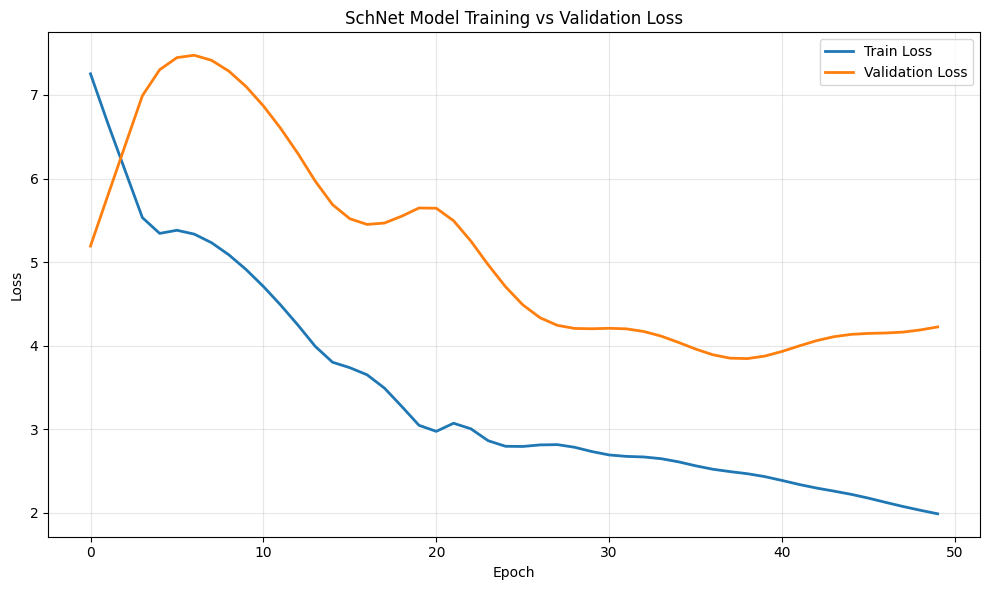

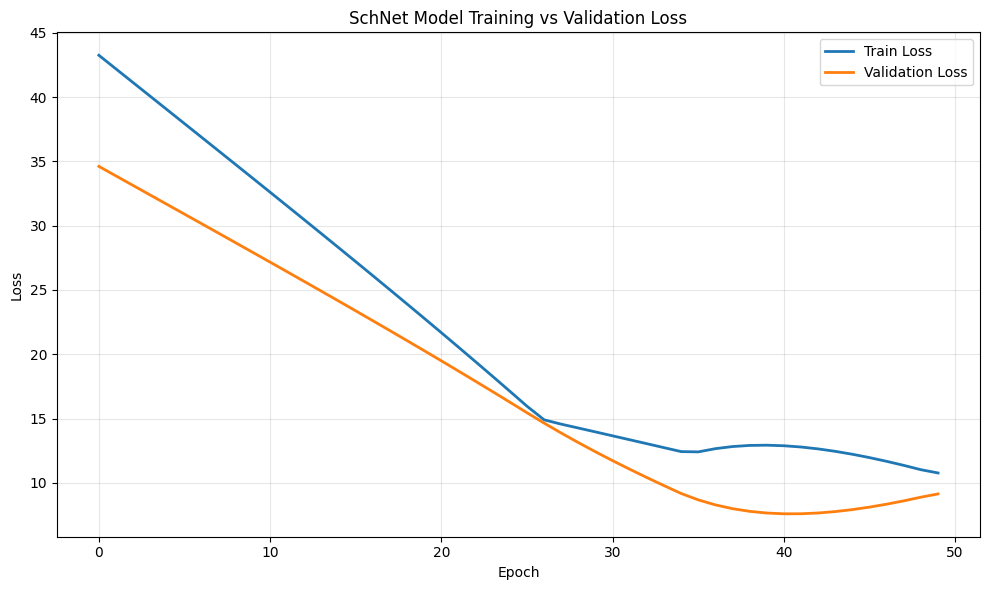

In [17]:
# ================================== Run Baseline Sweep =================================
#Determine the device to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#Initialize model with desired parameters
model = SchNetModel().to(device)
#Create ADAM optimizer based on model's parameters and desired learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
#Select loss function for model
loss_function = torch.nn.SmoothL1Loss()

# param_tuning(param = 'num_interactions',
#                  param_start = 1,
#                  param_end = 2,
#                  param_step = 1,
#                  file_path_to_save = '/content/drive/MyDrive/hyperparam_tuning',
#                  train_data = train_loader,
#                  val_data = val_loader,
#                  test_data = test_loader)

In [36]:
params_test_1 = [hidden_channels, num_filters]

baseline_sweep(params_to_optimize = params_test_1,
               filename = 'test_1',
               file_path_to_save = '/content/drive/MyDrive/hyperparam_tuning',
               train_data = train_loader,
               val_loader = val_loader,
               test_data = test_loader)

hyperparameter: hidden_channels, value: 1
6.871484756469727, 6.875915466392571
hyperparameter: hidden_channels, value: 2
3.500908851623535, 4.5475970871403915
hyperparameter: num_filters, value: 1
10.5674409866333, 11.70166788847087
hyperparameter: num_filters, value: 2
2.7753610610961914, 3.5135882772156317
